# Loan Approval Prediction

## Objective
The objective of this project is to build a machine learning model capable of predicting whether a loan application will be approved based on applicant information.

## Business Problem
Financial institutions receive thousands of loan applications. Manually evaluating every application is time-consuming and prone to inconsistencies. Predictive modeling can help identify potentially eligible applicants and support faster decision-making.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv('loan_prediction[1].csv')

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 614
Columns: 13


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [6]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
df.describe(include='object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


### Observation

- Dataset contains both numerical and categorical features.
- Loan_Status is the target variable.
- Several columns contain missing values.
- Loan_ID appears to be a unique identifier and will not contribute to prediction.

In [8]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Gender,13
Married,3
Dependents,15
Self_Employed,32
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50


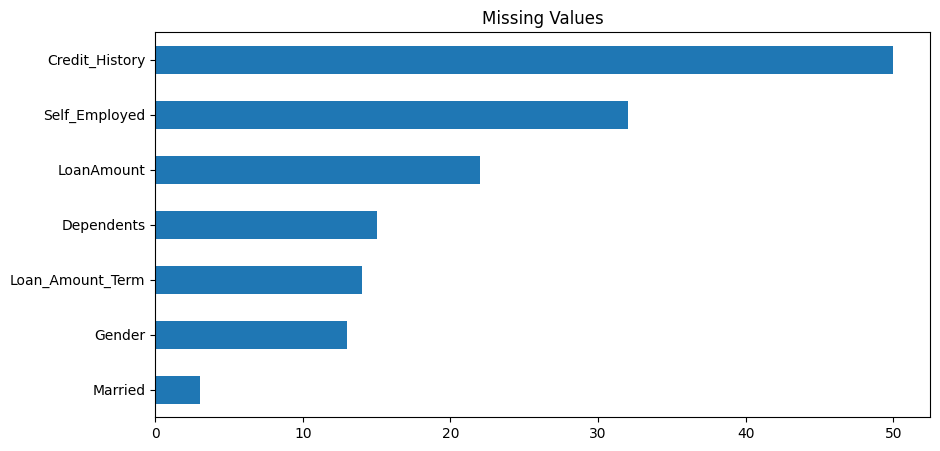

In [9]:
plt.figure(figsize=(10,5))

missing[missing>0].sort_values().plot(kind='barh')

plt.title("Missing Values")
plt.show()

In [10]:
df.drop("Loan_ID", axis=1, inplace=True)

In [11]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [12]:
numerical_cols = [
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [13]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


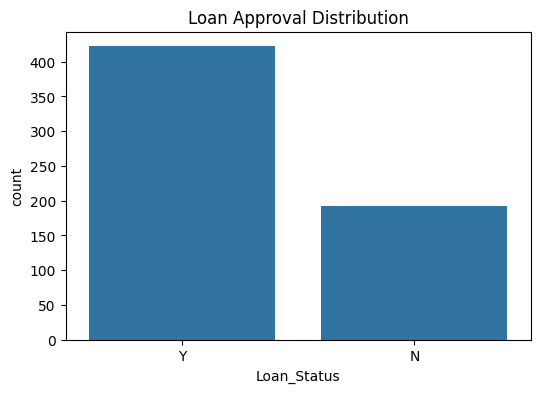

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Approval Distribution")
plt.show()

Most loan applications were approved, indicating a class imbalance.

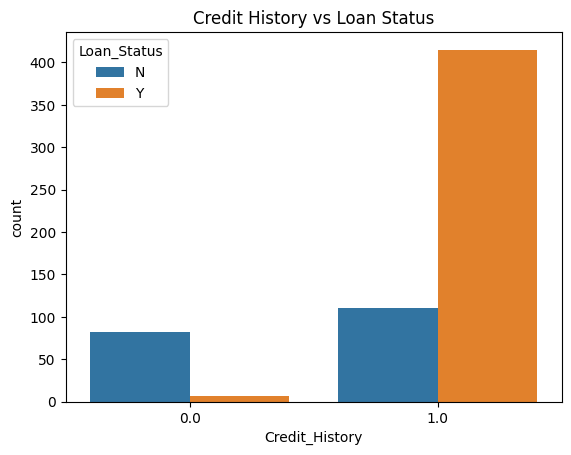

In [15]:
sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df
)

plt.title("Credit History vs Loan Status")
plt.show()

Applicants with a credit history are significantly more likely to receive loan approval.

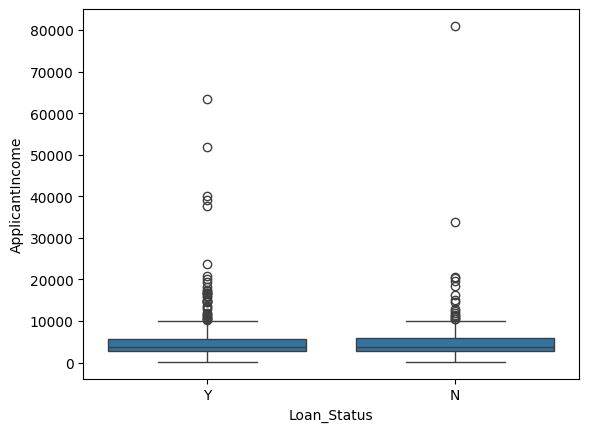

In [16]:
sns.boxplot(
    x='Loan_Status',
    y='ApplicantIncome',
    data=df
)

plt.show()

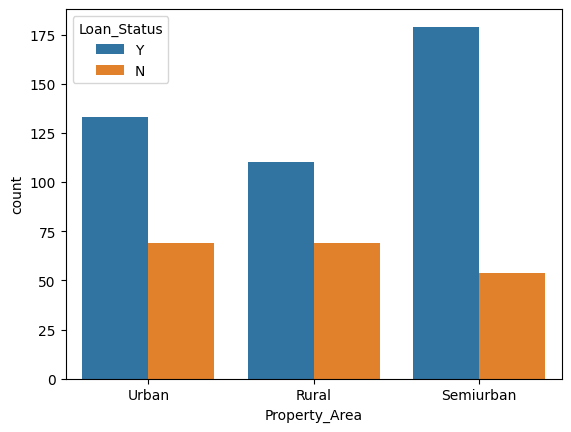

In [17]:
sns.countplot(
    x='Property_Area',
    hue='Loan_Status',
    data=df
)

plt.show()

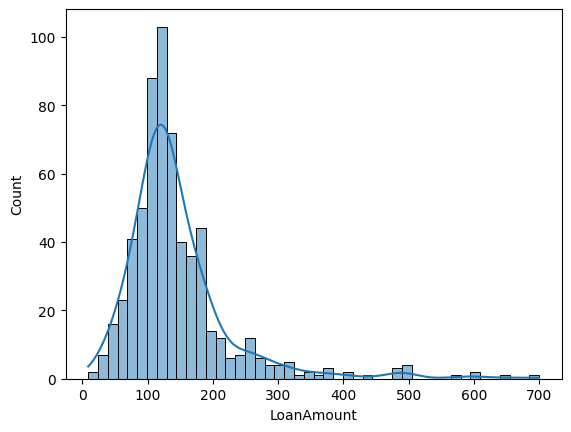

In [18]:
sns.histplot(
    df['LoanAmount'],
    kde=True
)

plt.show()

In [19]:
df['Dependents'] = df['Dependents'].replace('3+', 3)

df['Dependents'] = df['Dependents'].astype(int)

In [20]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

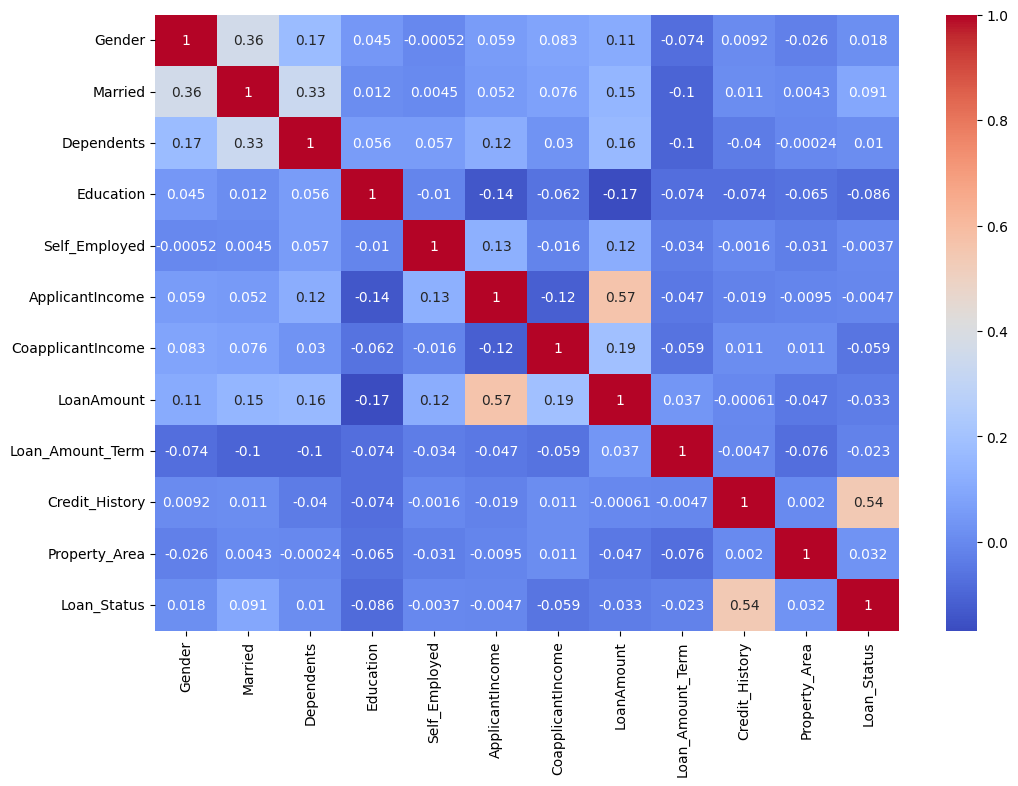

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [22]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

In [26]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

y_prob_lr = lr.predict_proba(X_test)[:,1]

In [27]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [28]:
def evaluate_model(y_true, y_pred, y_prob):

    print("Accuracy :", accuracy_score(y_true,y_pred))

    print("Precision :", precision_score(y_true,y_pred))

    print("Recall :", recall_score(y_true,y_pred))

    print("F1 Score :", f1_score(y_true,y_pred))

    print("ROC AUC :", roc_auc_score(y_true,y_prob))

In [29]:
print("Logistic Regression")

evaluate_model(
    y_test,
    y_pred_lr,
    y_prob_lr
)

Logistic Regression
Accuracy : 0.8373983739837398
Precision : 0.8494623655913979
Recall : 0.9294117647058824
F1 Score : 0.8876404494382022
ROC AUC : 0.8334365325077401


In [30]:
print("Random Forest")

evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf
)

Random Forest
Accuracy : 0.8048780487804879
Precision : 0.8426966292134831
Recall : 0.8823529411764706
F1 Score : 0.8620689655172413
ROC AUC : 0.7724458204334366


In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

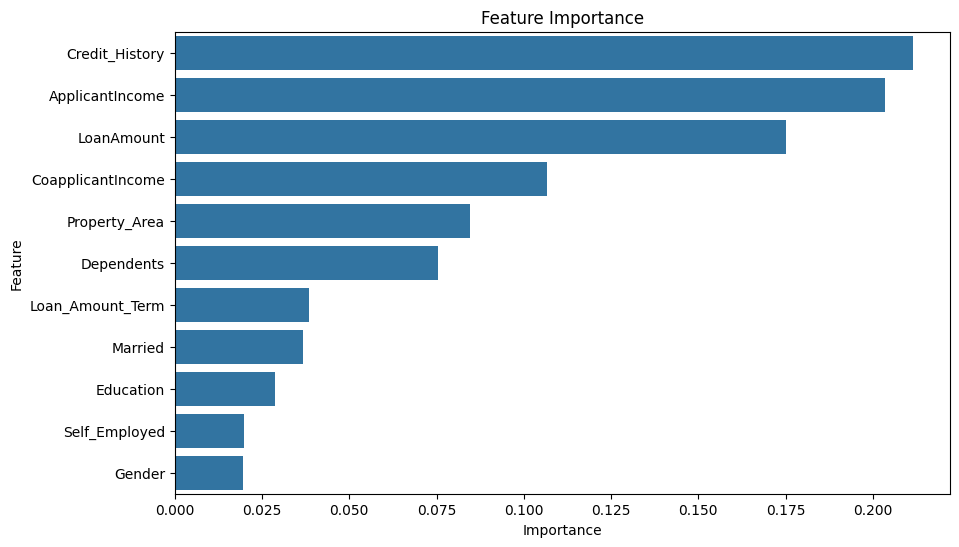

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance")
plt.show()

# Key Findings

1. Credit History emerged as the most influential factor affecting loan approval decisions. Applicants with a positive credit history had a significantly higher probability of loan approval.

2. Applicant Income showed a positive relationship with loan approval. Higher-income applicants were generally more likely to receive loan approval.

3. Loan Amount influenced approval decisions, with larger loan amounts often requiring stronger financial credentials and credit records.

4. Property Area contributed to loan approval patterns, with Semiurban applicants showing comparatively higher approval rates than Urban and Rural applicants.

5. Among the evaluated models, Random Forest outperformed Logistic Regression in terms of overall predictive performance, achieving better Precision, Recall, F1-Score, and ROC-AUC values.
